In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
result = pd.read_csv("results.csv")
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,AN_GNG_125,CB2947,2,True,False,False,False,False,False,4.821769e-07
1,AN_GNG_125,CB2947,3,True,True,False,False,False,False,5.283513e-06
2,AN_GNG_125,CB2947,4,True,True,True,False,False,False,1.489420e-05
3,AN_GNG_125,CB2947,5,True,True,True,False,False,False,2.665478e-05
4,AN_GNG_125,MBON19,2,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...
39995,CB3449,AN_AVLP_10,5,True,True,False,False,False,False,7.034247e-07
39996,CB3449,CB0858,2,False,False,False,False,False,False,NaN
39997,CB3449,CB0858,3,True,True,False,False,False,False,5.521100e-07
39998,CB3449,CB0858,4,True,True,False,False,False,False,3.042436e-06


In [3]:
# make longer: all columns starting with 'threshold'
result = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result['threshold'] = result['threshold'].str.replace('threshold_','')
result['plen'] = result['plen'].astype(str)

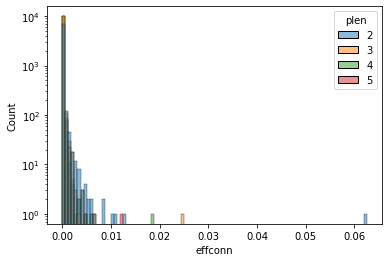

In [7]:
sns.histplot(data=result[result.effconn.notna()].drop_duplicates(['pre','post','plen']), x="effconn", hue='plen', bins = 100)
plt.yscale('log')
# plt.xscale('log')

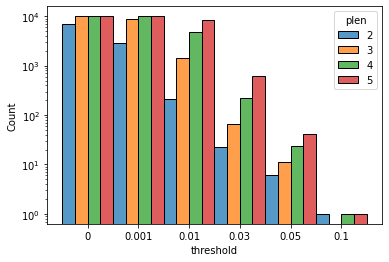

In [8]:
sns.histplot(result[result.value], x='threshold', hue='plen', multiple="dodge")
plt.yscale('log')

In [9]:
result[result.value][['plen','threshold']].value_counts()

plen  threshold
4     0            10000
5     0.001        10000
      0            10000
4     0.001         9984
3     0             9972
      0.001         8956
5     0.01          8388
2     0             6968
4     0.01          4847
2     0.001         2927
3     0.01          1450
5     0.03           623
4     0.03           217
2     0.01           211
3     0.03            66
5     0.05            41
4     0.05            24
2     0.03            23
3     0.05            11
2     0.05             6
      0.1              1
4     0.1              1
5     0.1              1
Name: count, dtype: int64